# Customer Segmentation Using RFM Analysis

## Project Overview

Customer segmentation is a fundamental technique in customer analytics that helps businesses understand purchasing behavior and develop personalized marketing strategies.

This project applies the **RFM (Recency, Frequency, Monetary)** framework combined with **K-Means clustering** to segment customers into meaningful groups based on their purchasing patterns.

The final output is a set of actionable customer segments that can support marketing campaigns, customer retention, and revenue optimization.

---

## Objectives

- Analyze customer purchasing behavior
- Calculate RFM metrics
- Cluster customers using K-Means
- Assign business-friendly customer segments
- Generate actionable business insights

# Business Problem

Businesses often treat all customers equally, despite significant differences in purchasing behavior.

The objective of this project is to identify different customer groups based on:

- How recently they purchased (Recency)
- How frequently they purchase (Frequency)
- How much they spend (Monetary)

These customer segments enable businesses to:

- Personalize marketing campaigns
- Improve customer retention
- Increase customer lifetime value
- Allocate marketing budgets more efficiently

### Import Libraries

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

plt.style.use("ggplot")

### Load Dataset

In [2]:
# Load dataset
df = pd.read_excel("../data/RFM.xlsx")

# Display first rows
df.head()

,UserID,R,F,M
0,12337,741,25,2210000
1,12338,1661,0,0
2,12339,936,2,520000
3,12341,1414,0,200000
4,12353,2092,0,100000


### Dataset Overview

In [3]:
print(f"Rows: {df.shape[0]}")
print(f"Columns: {df.shape[1]}")

df.info()

Rows: 2000
Columns: 4
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   UserID  2000 non-null   int64
 1   R       2000 non-null   int64
 2   F       2000 non-null   int64
 3   M       2000 non-null   int64
dtypes: int64(4)
memory usage: 62.6 KB


In [4]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
UserID,2000.0,5.157676e+04,2.264980e+04,12337.0,30886.75,53177.5,73351.25,84587.0
R,2000.0,1.078101e+03,7.333333e+02,0.0,460.25,970.5,1585.00,2436.0
F,2000.0,7.922850e+01,2.211411e+02,0.0,0.00,0.0,41.00,2153.0
M,2000.0,2.095458e+06,5.801901e+06,0.0,200000.00,521000.0,1555000.00,130330000.0


In [5]:
df.isnull().sum()

UserID    0
R         0
F         0
M         0
dtype: int64

In [6]:
df.duplicated().sum()

np.int64(0)

# Exploratory Data Analysis

Before building the segmentation model, we explore the distributions of the three RFM metrics.

Understanding their distributions helps identify skewness, outliers, and customer purchasing behavior.

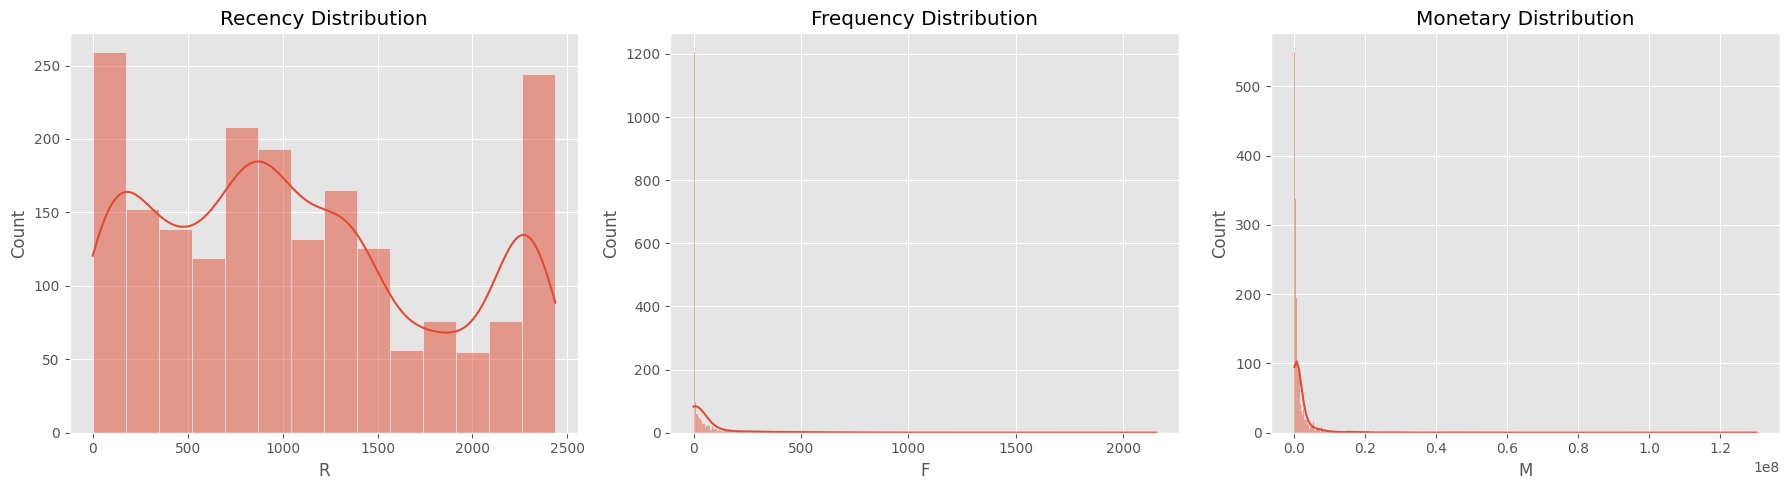

In [7]:
fig, axes = plt.subplots(1,3,figsize=(18,5))

sns.histplot(df["R"], kde=True, ax=axes[0])
axes[0].set_title("Recency Distribution")

sns.histplot(df["F"], kde=True, ax=axes[1])
axes[1].set_title("Frequency Distribution")

sns.histplot(df["M"], kde=True, ax=axes[2])
axes[2].set_title("Monetary Distribution")

plt.tight_layout()

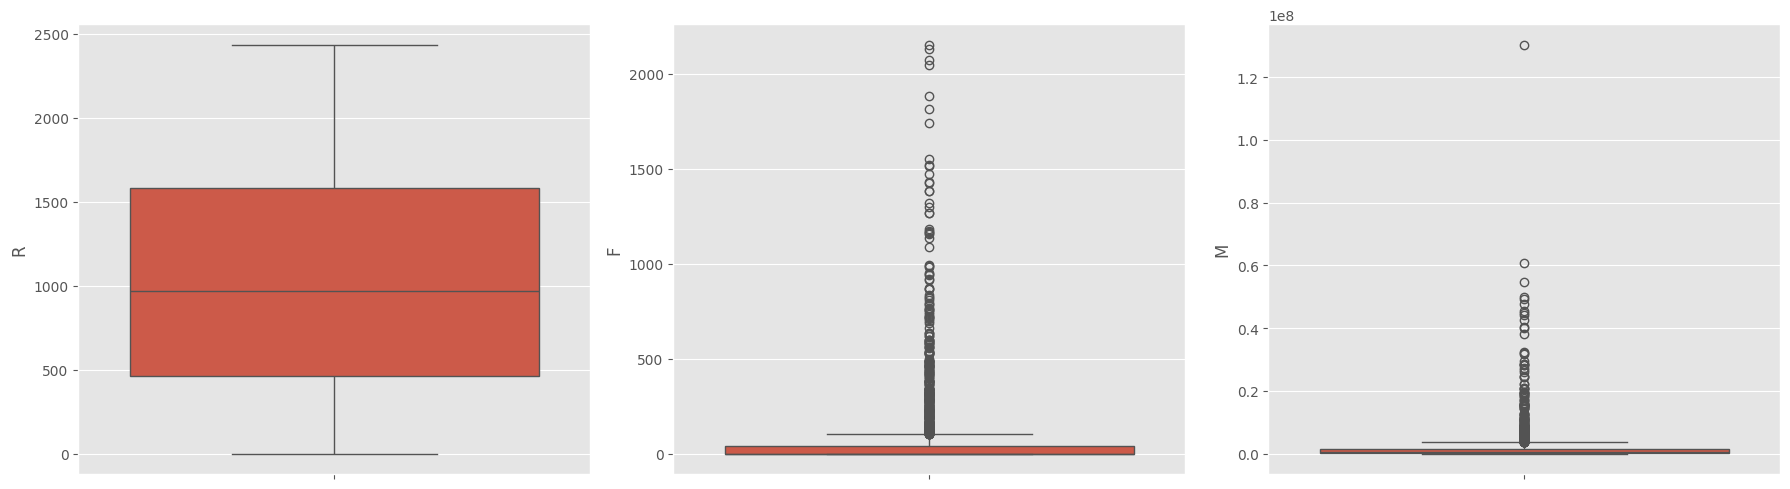

In [8]:
fig, axes = plt.subplots(1,3,figsize=(18,5))

sns.boxplot(y=df["R"], ax=axes[0])

sns.boxplot(y=df["F"], ax=axes[1])

sns.boxplot(y=df["M"], ax=axes[2])

plt.tight_layout()

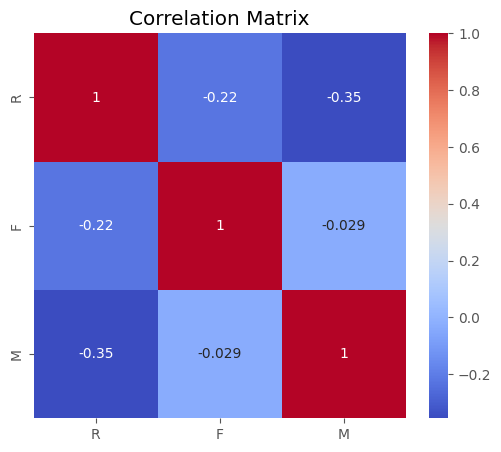

In [9]:
plt.figure(figsize=(6,5))

sns.heatmap(
    df[["R","F","M"]].corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Matrix")
plt.show()

# Feature Engineering

The dataset already contains the three RFM metrics:

- **Recency (R):** Number of days since the customer's last purchase.
- **Frequency (F):** Total number of purchases made by the customer.
- **Monetary (M):** Total amount spent by the customer.

These three features will be used to perform customer segmentation using K-Means clustering.

Instead of assigning arbitrary thresholds, clustering allows the data itself to define natural customer groups.

### Select RFM Features

In [10]:
rfm = df[['R', 'F', 'M']].copy()

rfm.head()

,R,F,M
0,741,25,2210000
1,1661,0,0
2,936,2,520000
3,1414,0,200000
4,2092,0,100000


# Customer Scoring Using K-Means

Traditional RFM analysis often divides customers using fixed quantiles.

In this project, we use **K-Means clustering** to identify natural groupings in each RFM metric.

Each metric is clustered into **5 groups**, corresponding to the standard RFM scoring system (1–5).

This approach is more data-driven and adapts to the distribution of the dataset.

In [11]:
from sklearn.cluster import KMeans

def cluster_feature(data, feature_name, n_clusters=5):
    """
    Cluster a single feature using K-Means.
    Returns cluster labels.
    """

    model = KMeans(
        n_clusters=n_clusters,
        random_state=42,
        n_init=10
    )

    clusters = model.fit_predict(data[[feature_name]])

    return clusters

### Cluster Each Metric

In [12]:
rfm["R_cluster"] = cluster_feature(rfm, "R")
rfm["F_cluster"] = cluster_feature(rfm, "F")
rfm["M_cluster"] = cluster_feature(rfm, "M")

rfm.head()

,R,F,M,R_cluster,F_cluster,M_cluster
0,741,25,2210000,0,0,1
1,1661,0,0,4,0,1
2,936,2,520000,0,0,1
3,1414,0,200000,2,0,1
4,2092,0,100000,1,0,1


### Cluster Summary

In [13]:
for feature in ["R", "F", "M"]:

    cluster_col = feature[0] + "_cluster"

    print("=" * 50)
    print(feature)

    display(
        rfm
        .groupby(cluster_col)[feature]
        .agg(["min","mean","max","count"])
        .round(2)
    )

R


,min,mean,max,count
R_cluster,,,,
0,494,785.10,1031,525
1,2034,2272.92,2436,337
2,1033,1274.92,1529,431
3,0,200.13,493,526
4,1532,1786.15,2025,181


F


,min,mean,max,count
F_cluster,,,,
0,0,12.32,115,1704
1,688,880.32,1184,38
2,360,483.67,662,78
3,1269,1614.05,2153,19
4,118,221.25,344,161


M


,min,mean,max,count
M_cluster,,,,
0,3790000,6.655466e+06,13070000,175
1,0,7.650267e+05,3700000,1764
2,38220000,4.651115e+07,60855750,12
3,14340000,2.058829e+07,32338000,48
4,130330000,1.303300e+08,130330000,1


# Reordering Cluster Labels

K-Means assigns cluster labels randomly.

For example, cluster **0** is not necessarily the lowest-value group.

To create meaningful RFM scores, the clusters are reordered based on the average value of each feature.

This ensures that:

- Lower Recency → Higher score
- Higher Frequency → Higher score
- Higher Monetary → Higher score

### Generic Ordering Function

In [14]:
def order_clusters(df, cluster_col, value_col, ascending=True):

    cluster_order = (
        df
        .groupby(cluster_col)[value_col]
        .mean()
        .sort_values(ascending=ascending)
        .reset_index()
    )

    cluster_order["Score"] = range(1, len(cluster_order)+1)

    mapping = dict(zip(cluster_order[cluster_col],
                       cluster_order["Score"]))

    df[cluster_col] = df[cluster_col].map(mapping)

    return df

### Assign Scores

In [15]:
# Recency
rfm = order_clusters(
    rfm,
    "R_cluster",
    "R",
    ascending=False
)

# Frequency
rfm = order_clusters(
    rfm,
    "F_cluster",
    "F",
    ascending=True
)

# Monetary
rfm = order_clusters(
    rfm,
    "M_cluster",
    "M",
    ascending=True
)

### Rename Scores

In [16]:
rfm.rename(columns={
    "R_cluster":"R_Score",
    "F_cluster":"F_Score",
    "M_cluster":"M_Score"
}, inplace=True)

rfm.head()

,R,F,M,R_Score,F_Score,M_Score
0,741,25,2210000,4,1,1
1,1661,0,0,2,1,1
2,936,2,520000,4,1,1
3,1414,0,200000,3,1,1
4,2092,0,100000,1,1,1


### Create Final RFM Score

In [17]:
rfm["RFM_Score"] = (
    rfm["R_Score"].astype(str)
    + rfm["F_Score"].astype(str)
    + rfm["M_Score"].astype(str)
)

rfm.head()

,R,F,M,R_Score,F_Score,M_Score,RFM_Score
0,741,25,2210000,4,1,1,411
1,1661,0,0,2,1,1,211
2,936,2,520000,4,1,1,411
3,1414,0,200000,3,1,1,311
4,2092,0,100000,1,1,1,111


### Score Distribution

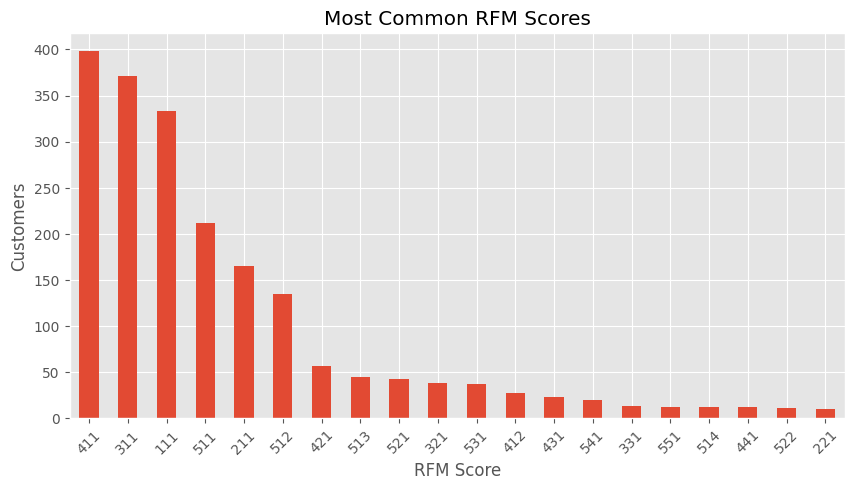

In [18]:
plt.figure(figsize=(10,5))

rfm["RFM_Score"].value_counts().head(20).plot(kind="bar")

plt.title("Most Common RFM Scores")

plt.xlabel("RFM Score")

plt.ylabel("Customers")

plt.xticks(rotation=45)

plt.show()

# Customer Segmentation

After calculating the RFM scores, customers are grouped into meaningful business segments.

Each segment represents a different purchasing behavior and can be targeted with specific marketing strategies.

The segmentation rules are based on the Recency and Frequency scores, while the Monetary score provides additional context.

### Assign Segment Labels

In [19]:
def assign_segment(row):

    r = row["R_Score"]
    f = row["F_Score"]

    if r >= 5 and f >= 5:
        return "Champions"

    elif r >= 4 and f >= 4:
        return "Loyal Customers"

    elif r >= 4 and f >= 2:
        return "Potential Loyalists"

    elif r >= 5 and f == 1:
        return "New Customers"

    elif r == 3 and f >= 3:
        return "Need Attention"

    elif r == 3 and f <= 2:
        return "About to Sleep"

    elif r <= 2 and f >= 4:
        return "Can't Lose Them"

    elif r <= 2 and f >= 2:
        return "At Risk"

    elif r == 1 and f == 1:
        return "Lost"

    else:
        return "Hibernating"


rfm["Segment"] = rfm.apply(assign_segment, axis=1)

In [26]:
rfm.head()

,R,F,M,R_Score,F_Score,M_Score,RFM_Score,Segment
0,741,25,2210000,4,1,1,411,Hibernating
1,1661,0,0,2,1,1,211,Hibernating
2,936,2,520000,4,1,1,411,Hibernating
3,1414,0,200000,3,1,1,311,About to Sleep
4,2092,0,100000,1,1,1,111,Lost


### Sava Output as a CSV 

In [28]:
rfm_score_tag = rfm.drop(columns=["R_Score", "F_Score", "M_Score"])
rfm_score_tag.head()

,R,F,M,RFM_Score,Segment
0,741,25,2210000,411,Hibernating
1,1661,0,0,211,Hibernating
2,936,2,520000,411,Hibernating
3,1414,0,200000,311,About to Sleep
4,2092,0,100000,111,Lost


In [31]:
rfm_score_tag.to_csv("../data/rfm_score_tag.csv")

### Segment Distribution

In [20]:
segment_summary = (
    rfm["Segment"]
    .value_counts()
    .rename_axis("Segment")
    .reset_index(name="Customers")
)

segment_summary

,Segment,Customers
0,Hibernating,594
1,About to Sleep,411
2,New Customers,404
3,Lost,333
4,Potential Loyalists,169
5,Loyal Customers,38
6,Need Attention,20
7,At Risk,19
8,Champions,12


### Segment Statistics

In [21]:
segment_profile = (
    rfm
    .groupby("Segment")
    .agg(
        Customers=("Segment", "count"),
        Avg_Recency=("R", "mean"),
        Avg_Frequency=("F", "mean"),
        Avg_Monetary=("M", "mean")
    )
    .round(2)
    .sort_values("Customers", ascending=False)
)

segment_profile

,Customers,Avg_Recency,Avg_Frequency,Avg_Monetary
Segment,,,,
Hibernating,594,1068.67,11.91,1025308.92
About to Sleep,411,1276.06,27.61,808905.11
New Customers,404,192.47,23.77,6974257.43
Lost,333,2274.74,3.58,132987.99
Potential Loyalists,169,477.97,319.91,1831136.39
Loyal Customers,38,466.34,973.24,1237000.00
Need Attention,20,1251.60,652.80,400300.00
At Risk,19,1876.11,253.37,315000.00
Champions,12,211.25,1693.25,1423166.67


### Visualize Customer Segments

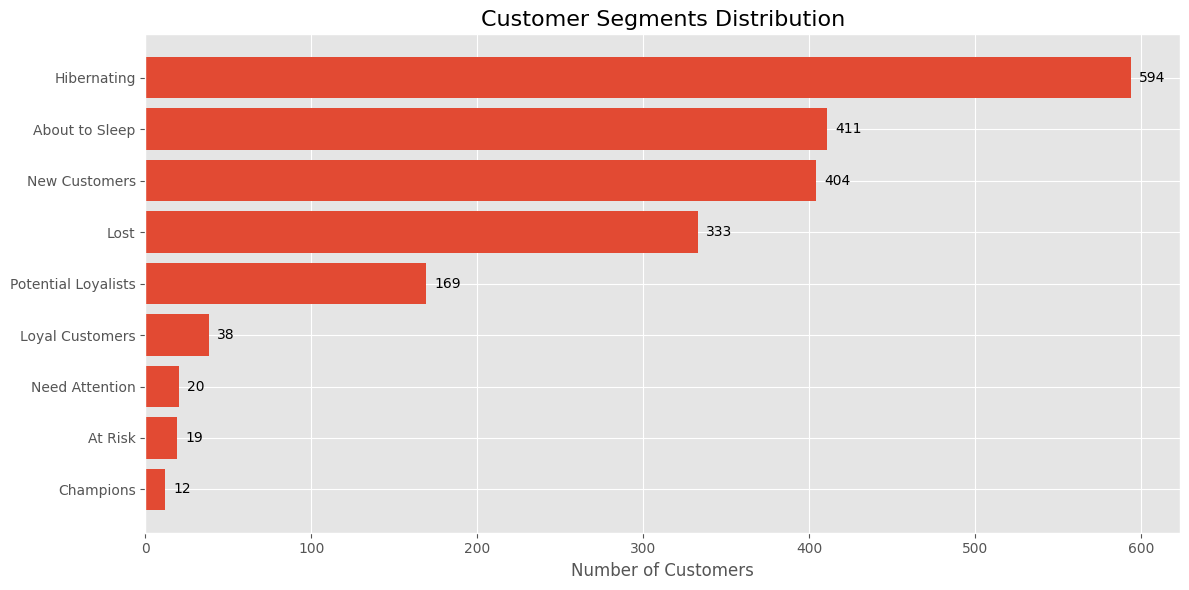

In [22]:
plt.figure(figsize=(12,6))

order = segment_summary.sort_values("Customers")

bars = plt.barh(
    order["Segment"],
    order["Customers"]
)

plt.title("Customer Segments Distribution", fontsize=16)

plt.xlabel("Number of Customers")

for bar in bars:
    width = bar.get_width()
    plt.text(
        width + 5,
        bar.get_y() + bar.get_height()/2,
        f"{int(width)}",
        va="center"
    )

plt.tight_layout()
plt.show()

### Segment Percentages

In [23]:
segment_summary["Percentage"] = (
    segment_summary["Customers"]
    / segment_summary["Customers"].sum()
    * 100
).round(2)

segment_summary

,Segment,Customers,Percentage
0,Hibernating,594,29.70
1,About to Sleep,411,20.55
2,New Customers,404,20.20
3,Lost,333,16.65
4,Potential Loyalists,169,8.45
5,Loyal Customers,38,1.90
6,Need Attention,20,1.00
7,At Risk,19,0.95
8,Champions,12,0.60


### Tree Map Using Plotly
-**plotly interactive output may not be available on github**

In [24]:
import plotly.express as px

segment_summary = (
    rfm["Segment"]
    .value_counts()
    .reset_index()
)

segment_summary.columns = ["Segment", "Customers"]

fig = px.treemap(
    segment_summary,
    path=["Segment"],
    values="Customers",
    color="Customers",
    color_continuous_scale="Blues",
)

fig.update_traces(
    textinfo="label+value+percent root",
    textfont_size=18,
)

fig.update_layout(
    title="Customer Segment Distribution",
    title_x=0.5,
    margin=dict(t=60, l=20, r=20, b=20)
)

fig.show()